In [1]:
!pip install torch torchvision

import torch
import torchvision
from torchvision import transforms
from torch import nn
import torch.nn.functional as F
import numpy as np
import matplotlib
from matplotlib import pyplot as plt


np.random.seed(1234)
torch.manual_seed(1234)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Found device : {device}")

Found device : cuda


In [2]:
# When we load the data, they exist as as PIL images, convert to tensors, cell values are in [0, 1] so we don't need to normalize them.
transform = transforms.Compose([transforms.ToTensor()])

# load dataset
data_folder = "./fashionMNIST"
train_data = torchvision.datasets.FashionMNIST(data_folder, train=True, download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST(data_folder, train=False, download=True, transform=transform)

# split training data into training and validation sets
train_data, valid_data = torch.utils.data.random_split(train_data, [50000,10000]) # 50k train, 10k validation

batch_size =1000
# data iterators
train_set  = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=batch_size)
valid_set  = torch.utils.data.DataLoader(valid_data, shuffle=False, batch_size=batch_size)
test_set   = torch.utils.data.DataLoader(test_data,  shuffle=False, batch_size=batch_size)



100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 174kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.4MB/s]


In [3]:

# Model definition

class EncoderDeep(nn.Module):
    def __init__(self, n_components):
        super().__init__()
        self.fc1 = nn.Linear(784, 1000)
        self.fc2 = nn.Linear(1000, 500)
        self.fc3 = nn.Linear(500, 250)
        self.fc_mu = nn.Linear(250, n_components)
        self.fc_logvar = nn.Linear(250, n_components)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


class DecoderDeep(nn.Module):
    def __init__(self, n_components):
        super().__init__()
        self.fc1 = nn.Linear(n_components, 250)
        self.fc2 = nn.Linear(250, 500)
        self.fc3 = nn.Linear(500, 1000)
        self.fc4 = nn.Linear(1000, 784)

    def forward(self, z):
        z = F.relu(self.fc1(z))
        z = F.relu(self.fc2(z))
        z = F.relu(self.fc3(z))
        z = torch.sigmoid(self.fc4(z))
        return z.view(-1, 1, 28, 28)


def reparameterize(mu, logvar):
    """Sample z = mu + std * eps, where eps ~ N(0, I)."""
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std


def kl_divergence_standard_normal(mu, logvar):
    """KL(N(mu, sigma^2) || N(0, I)) for a diagonal Gaussian.

    Returns one KL value per input image, so the training loop can decide how to average it.
    """
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)


In [4]:

# Training setup
n_components = 2  # 2-dimensional latent space, convenient for plotting
encoder = EncoderDeep(n_components=n_components).to(device)
decoder = DecoderDeep(n_components=n_components).to(device)

params = list(encoder.parameters()) + list(decoder.parameters())
optimizer = torch.optim.Adam(params=params, lr=1e-3)

# Decoder already applies sigmoid, so BCELoss is appropriate here.
criterion = nn.BCELoss(reduction='sum')


In [5]:

def show_image_grid(images, n_cols=5, figsize=(8, 4), title=None):
    """Display a batch of FashionMNIST-like images."""
    images = images.detach().cpu().view(-1, 28, 28)
    n_images = images.size(0)
    n_rows = int(np.ceil(n_images / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.atleast_1d(axes).reshape(n_rows, n_cols)

    for ax in axes.ravel():
        ax.axis('off')

    for i, ax in enumerate(axes.ravel()[:n_images]):
        ax.imshow(images[i], cmap='gray')

    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def generate_from_z(z_values):
    """Decode user-provided latent vectors.

    Example for a 2D latent space:
        generate_from_z([[0, 0], [1, -1], [-2, 0.5]])
    """
    z = torch.as_tensor(z_values, dtype=torch.float32, device=device)
    if z.ndim == 1:
        z = z.unsqueeze(0)
    if z.size(1) != n_components:
        raise ValueError(f'Each z must have {n_components} values, got shape {tuple(z.shape)}')

    decoder.eval()
    with torch.no_grad():
        generated = decoder(z)
    return generated


In [6]:

# KL optimization note
#
# The original notebook estimated KL(q(z|x) || p(z)) by sampling from q and comparing logpdf values.
# For diagonal Gaussians, the KL has a closed-form expression, implemented in
# kl_divergence_standard_normal(mu, logvar). It is faster, deterministic, and has lower gradient noise.


In [7]:

n_epochs = 10

encoder.train()
decoder.train()

kl_losses = []
recon_losses = []
elbo = []

for epoch in range(n_epochs):
    epoch_kl = []
    epoch_recon = []
    epoch_elbo = []

    for data, _ in train_set:
        data = data.to(device)
        current_batch_size = data.size(0)

        optimizer.zero_grad()

        z_mu, z_logvar = encoder(data)
        z = reparameterize(z_mu, z_logvar)
        reconstruction = decoder(z)

        loss_reconstruction = criterion(reconstruction, data) / current_batch_size
        loss_kl = kl_divergence_standard_normal(z_mu, z_logvar).mean()
        loss = loss_reconstruction + loss_kl

        loss.backward()
        optimizer.step()

        epoch_kl.append(loss_kl.item())
        epoch_recon.append(loss_reconstruction.item())
        epoch_elbo.append(loss.item())

    kl_losses.append(np.mean(epoch_kl))
    recon_losses.append(np.mean(epoch_recon))
    elbo.append(np.mean(epoch_elbo))

    print(
        f"Epoch {epoch:3d}  "
        f"Reconstruction Loss {recon_losses[-1]:.7f}  "
        f"KL Loss {kl_losses[-1]:.7f}  "
        f"ELBO {elbo[-1]:.7f}"
    )


Epoch   0  Reconstruction Loss 368.5477863  KL Loss 3.5547238  ELBO 372.1025128
Epoch   1  Reconstruction Loss 282.5613763  KL Loss 7.3739726  ELBO 289.9353467
Epoch   2  Reconstruction Loss 273.3063031  KL Loss 6.9411809  ELBO 280.2474829
Epoch   3  Reconstruction Loss 268.8941034  KL Loss 6.5699654  ELBO 275.4640686
Epoch   4  Reconstruction Loss 264.8899664  KL Loss 6.4047931  ELBO 271.2947607
Epoch   5  Reconstruction Loss 262.1794974  KL Loss 6.3438665  ELBO 268.5233636
Epoch   6  Reconstruction Loss 260.8466785  KL Loss 6.3094376  ELBO 267.1561163
Epoch   7  Reconstruction Loss 259.1803915  KL Loss 6.3161601  ELBO 265.4965515
Epoch   8  Reconstruction Loss 258.4846060  KL Loss 6.2908008  ELBO 264.7754077
Epoch   9  Reconstruction Loss 257.5860385  KL Loss 6.3001022  ELBO 263.8861395


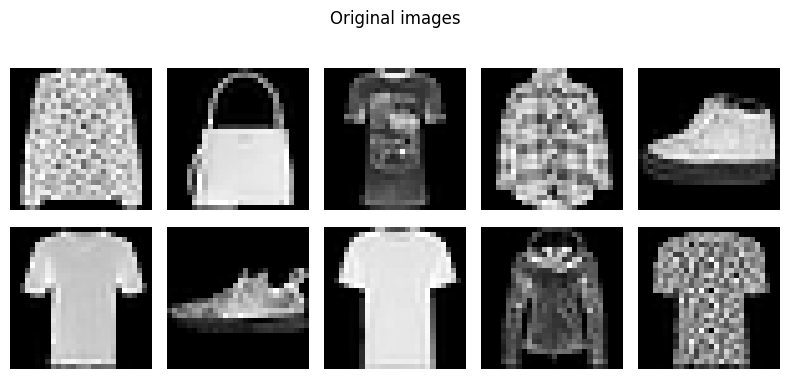

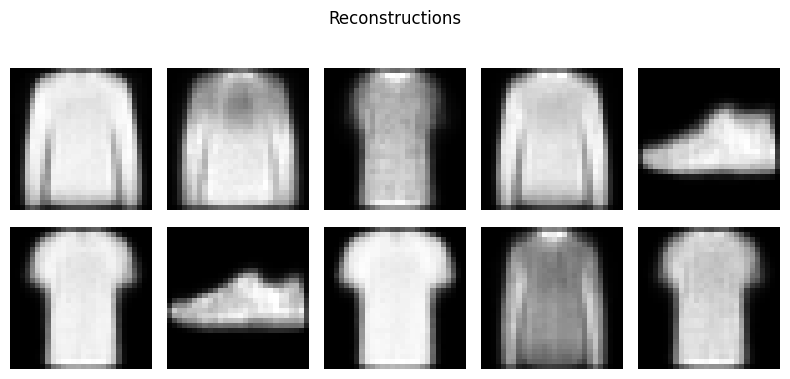

In [8]:

# Show reconstructions from the last training batch.
show_image_grid(data[:10], n_cols=5, title='Original images')
show_image_grid(reconstruction[:10], n_cols=5, title='Reconstructions')


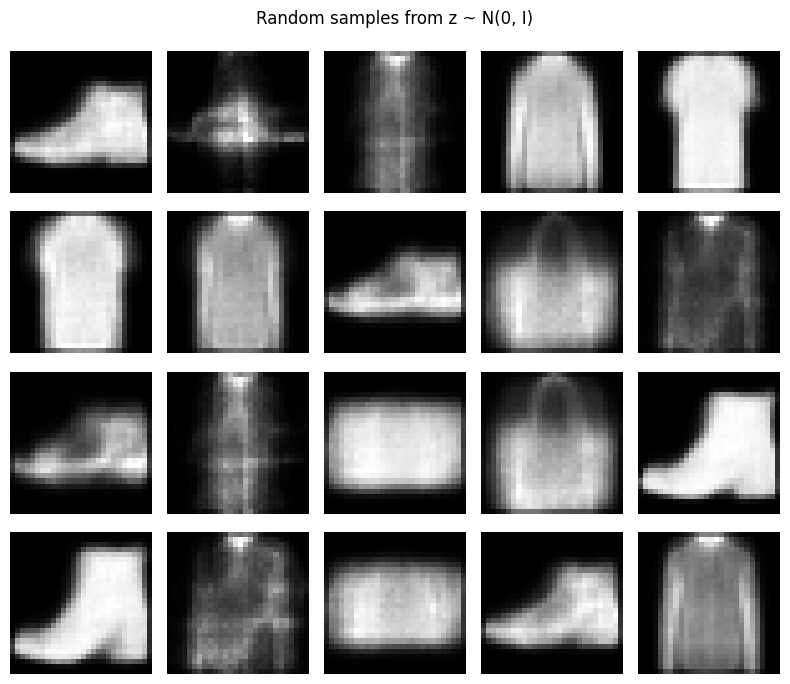

In [9]:

# Generate new images by sampling z from the standard Normal prior.
decoder.eval()
with torch.no_grad():
    z_random = torch.randn(20, n_components, device=device)
    x_random = decoder(z_random)

show_image_grid(x_random, n_cols=5, figsize=(8, 7), title='Random samples from z ~ N(0, I)')


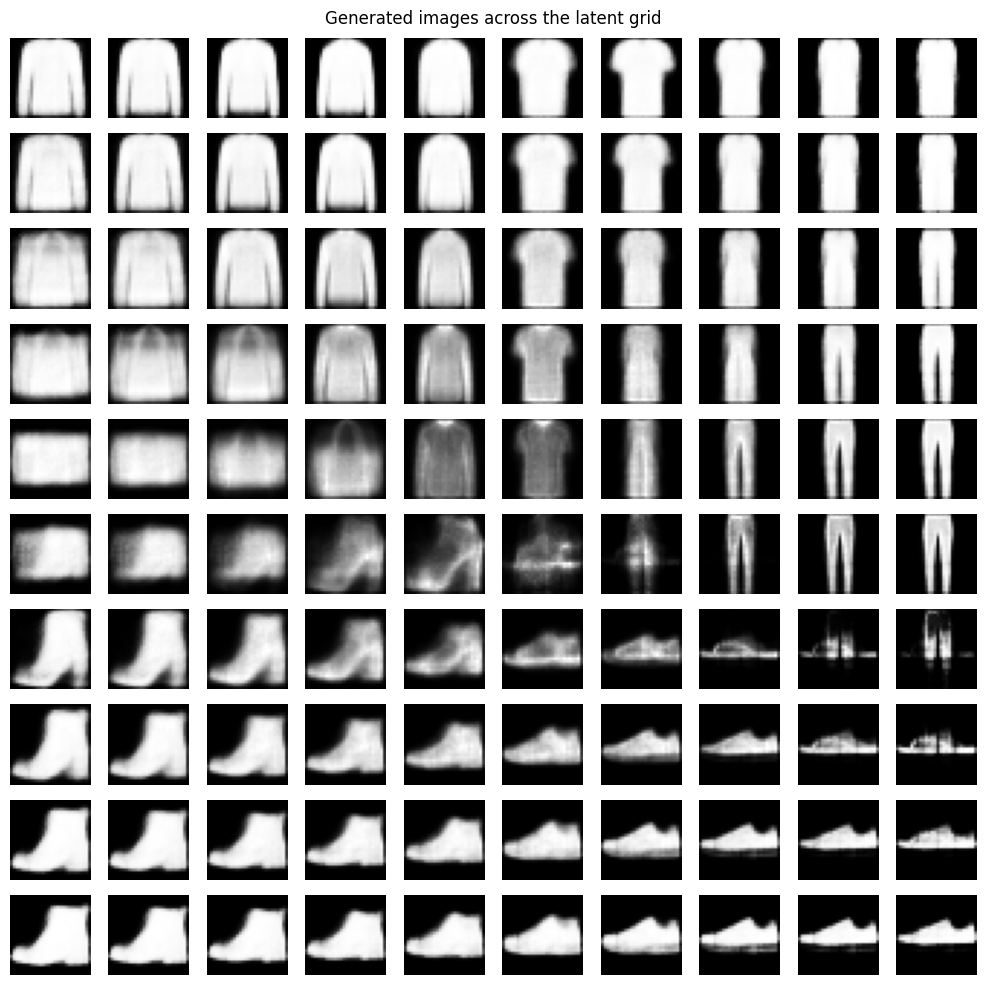

In [10]:

# Explore the 2D latent space on a grid.
if n_components != 2:
    raise ValueError('The latent grid visualization expects n_components == 2.')

x_axis = np.linspace(-3, 3, 10)
y_axis = np.linspace(-3, 3, 10)
grid_x, grid_y = np.meshgrid(x_axis, y_axis)
z_grid = np.stack([grid_x.ravel(), grid_y.ravel()], axis=1)

x_grid = generate_from_z(z_grid)
show_image_grid(x_grid, n_cols=10, figsize=(10, 10), title='Generated images across the latent grid')


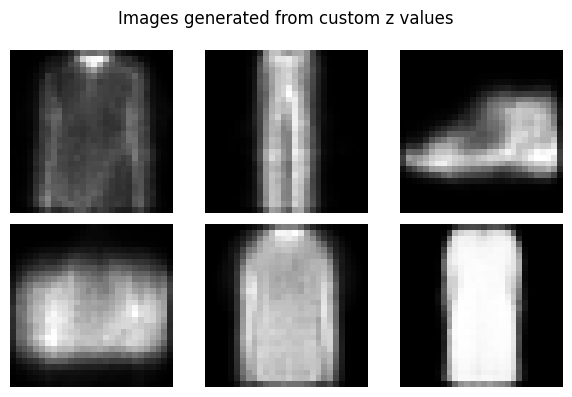

In [11]:

# User-defined latent vectors: change these z values and run the cell.
# Because n_components = 2, each row is [z1, z2].
custom_z = [
    [0.0, 0.0],
    [1.0, 0.0],
    [0.0, 1.0],
    [-1.0, 0.0],
    [0.0, -1.0],
    [2.0, -2.0],
]

custom_images = generate_from_z(custom_z)
show_image_grid(custom_images, n_cols=3, figsize=(6, 4), title='Images generated from custom z values')
